# COMBINED MODEL

## Import libraries:

In [69]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt  
from matplotlib.ticker import PercentFormatter
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis
import itertools
from collections import Counter

import os
import glob
import sys
current_directory = os.getcwd()
os.chdir(current_directory)
sys.path.append('./ML/')
from seq_utils import *
from ML_utils import *
import torch

import xgboost as xgb
#from antiberty import AntiBERTyRunner

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier,GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.multiclass import OneVsRestClassifier


## Load data:

In [70]:
# --- Read csv file:
Data = pd.read_csv('./Data/Datasets/Boughter_Jain_Shehata_data.csv',index_col=[0])

Data[:5]

,Name,Ab type,Dataset,L-CDR1,L-CDR2,L-CDR3,H-CDR1,H-CDR2,H-CDR3,VH,VL,VH_VL_joined,HL-CDRs_joined,H-CDRs_joined,L-CDRs_joined,react,PSR Score
0,0,Mouse IgA,Boughter,TDIDDD,EGN,LQSDNMPYTF,GYSITSDY,ISYSGST,ARRGYYYGSFDYW,QVQLKQSGPGLAKPSQTLSLTCSVTGYSITSDYWNWIRKFPGNKLE...,DIQMTQSPASLSVATGEKVTIRCITSTDIDDDMNWYQQKPGEPPKL...,QVQLKQSGPGLAKPSQTLSLTCSVTGYSITSDYWNWIRKFPGNKLE...,GYSITSDYISYSGSTARRGYYYGSFDYWTDIDDDEGNLQSDNMPYTF,GYSITSDYISYSGSTARRGYYYGSFDYW,TDIDDDEGNLQSDNMPYTF,0,NaN
1,1,Mouse IgA,Boughter,QEISGY,AAS,LQYASYPPTF,GYTFTSYW,IHPSDSDT,AIDYDQAMDYW,HSQLQESGAELVKPGASVKVSCKASGYTFTSYWMHWVKQRPGQGLE...,DIQMNQSPSSLSASLGERVSLTCRASQEISGYLSWLQQKPDGTIKR...,HSQLQESGAELVKPGASVKVSCKASGYTFTSYWMHWVKQRPGQGLE...,GYTFTSYWIHPSDSDTAIDYDQAMDYWQEISGYAASLQYASYPPTF,GYTFTSYWIHPSDSDTAIDYDQAMDYW,QEISGYAASLQYASYPPTF,0,NaN
2,2,Mouse IgA,Boughter,QDVGTA,WAS,QQYSSYPFTF,GYSITSGYY,ISYDGS,ARFYGNYEDYYAMDYW,QVQLKQSGPGLVKPSQSLSLTCSVTGYSITSGYYWNWIRQFPGNKL...,ETTVTQSHKFMSTSVGDRVSITCKASQDVGTAVAWYQQKPGQSPKL...,QVQLKQSGPGLVKPSQSLSLTCSVTGYSITSGYYWNWIRQFPGNKL...,GYSITSGYYISYDGSARFYGNYEDYYAMDYWQDVGTAWASQQYSSY...,GYSITSGYYISYDGSARFYGNYEDYYAMDYW,QDVGTAWASQQYSSYPFTF,0,NaN
3,3,Mouse IgA,Boughter,QDIGSS,AT,LQYASSPWTF,GFTFTDYY,IRNKANGYTT,ARLDSSGYDYAMDYW,EVQLLETGGGLVQPGGSLSLSCAASGFTFTDYYMSWVRQPPGKALE...,DIQMNQSPSSLSASLGERVSLTCRASQDIGSSLNWLQQEPDGTIKR...,EVQLLETGGGLVQPGGSLSLSCAASGFTFTDYYMSWVRQPPGKALE...,GFTFTDYYIRNKANGYTTARLDSSGYDYAMDYWQDIGSSATLQYAS...,GFTFTDYYIRNKANGYTTARLDSSGYDYAMDYW,QDIGSSATLQYASSPWTF,0,NaN
4,4,Mouse IgA,Boughter,QSIGTS,YAS,QQSNSWPLTF,GFTFSSYG,ISSGGSYT,ARQEGNSGEYYFDYW,EVKLEESGGDLVKPGGSLKLSCAASGFTFSSYGMSWVRQTPDKRLE...,ENVLTQSPAILSVSPGERVSFSCRASQSIGTSIHWYQQRTNGSPRL...,EVKLEESGGDLVKPGGSLKLSCAASGFTFSSYGMSWVRQTPDKRLE...,GFTFSSYGISSGGSYTARQEGNSGEYYFDYWQSIGTSYASQQSNSW...,GFTFSSYGISSGGSYTARQEGNSGEYYFDYW,QSIGTSYASQQSNSWPLTF,0,NaN


## Load embeddings:

### PLM-based embeddings:

In [71]:
# --- Load PLM-based embeddings:
directory = './Data/Embeddings'
emb_algoritms = ['AbLang2', 'AntiBERTy', 'esm1b_t33_650M_UR50S', 'esm1v_t33_650M_UR90S_1', 'esm2_t36_3B_UR50D', 'protbert_bfd']
Ab_type_list = ['VH', 'VL', 'VH-VL_joined', 'H-CDR1', 'H-CDR2', 'H-CDR3','L-CDR1', 'L-CDR2', 'L-CDR3','H-CDRs_joined', 'L-CDRs_joined','HL-CDRs_joined']
 
 
for emb in emb_algoritms:
    if 'esm1v' in emb:
        emb_short='esm1v'
    elif 'esm1b' in emb:
        emb_short='esm1b'
    elif 'esm2' in emb:
        emb_short='esm2'
    else:
        emb_short=emb
    try:
        for i, Ab_type in enumerate(Ab_type_list):
            mean_emd = torch.load(directory + '/' + str(emb) + '/' + 'tensor_' + str(emb) + '_' + str(Ab_type)+'.pt')
            mean_emd_list = [row.tolist() for row in mean_emd]
            col_name = str(emb_short) +'_'+ str(Ab_type)
            Data[col_name] = mean_emd_list
    except Exception as e:
        print(f"{type(e).__name__}")
        print(e)
        pass

Data.columns


Index(['Name', 'Ab type', 'Dataset', 'L-CDR1', 'L-CDR2', 'L-CDR3', 'H-CDR1',
       'H-CDR2', 'H-CDR3', 'VH', 'VL', 'VH_VL_joined', 'HL-CDRs_joined',
       'H-CDRs_joined', 'L-CDRs_joined', 'react', 'PSR Score', 'AbLang2_VH',
       'AbLang2_VL', 'AbLang2_VH-VL_joined', 'AbLang2_H-CDR1',
       'AbLang2_H-CDR2', 'AbLang2_H-CDR3', 'AbLang2_L-CDR1', 'AbLang2_L-CDR2',
       'AbLang2_L-CDR3', 'AbLang2_H-CDRs_joined', 'AbLang2_L-CDRs_joined',
       'AbLang2_HL-CDRs_joined', 'AntiBERTy_VH', 'AntiBERTy_VL',
       'AntiBERTy_VH-VL_joined', 'AntiBERTy_H-CDR1', 'AntiBERTy_H-CDR2',
       'AntiBERTy_H-CDR3', 'AntiBERTy_L-CDR1', 'AntiBERTy_L-CDR2',
       'AntiBERTy_L-CDR3', 'AntiBERTy_H-CDRs_joined',
       'AntiBERTy_L-CDRs_joined', 'AntiBERTy_HL-CDRs_joined', 'esm1b_VH',
       'esm1b_VL', 'esm1b_VH-VL_joined', 'esm1b_H-CDR1', 'esm1b_H-CDR2',
       'esm1b_H-CDR3', 'esm1b_L-CDR1', 'esm1b_L-CDR2', 'esm1b_L-CDR3',
       'esm1b_H-CDRs_joined', 'esm1b_L-CDRs_joined', 'esm1b_HL-CDRs_joined',
  

### Schrödinger descriptors:

In [72]:
# --- Load Schrödinger descriptors:
directory = './Data/Embeddings/Schrödinger_desc/Boughter_Jain_Shehata_datasets/'
Ab_type_list = ['VH', 'VL', 'VH-VL_joined', 'H-CDR1', 'H-CDR2', 'H-CDR3','L-CDR1', 'L-CDR2', 'L-CDR3','H-CDRs_joined', 'L-CDRs_joined','HL-CDRs_joined']

dict_Ab_type_desc = {}
for i, Ab_type in enumerate(Ab_type_list):
    path_desc = directory + str(Ab_type) + '/sequence_descriptors.csv'
    path_seq = directory + str(Ab_type) + '/'+ Ab_type +'.fasta'
    Data_desc = pd.read_csv(path_desc,index_col=0)
    schrod_desc = list(Data_desc.columns[2:])
    
    # --- Add theoretical pI:
    seq_list = [str(rec.seq) for rec in list(SeqIO.parse(path_seq, "fasta"))]
    id_list = [rec.id for rec in list(SeqIO.parse(path_seq, "fasta"))]
    Data_desc[Ab_type] = seq_list
    Data_desc['Theoretical pI'] = [ProteinAnalysis(seq).isoelectric_point() for seq in seq_list]
    Data_desc['Dataset'] = [name.split('_')[-1] for name in list(Data_desc['Name'])]
    
    # --- Add react in df_data:
    Data_desc['react'] = list(Data['react'])
    Data_desc['PSR Score'] = list(Data['PSR Score'])
    Data_desc['Ab type'] = list(Data['Ab type'])
    
    # --- Re-arrange columns:
    Data_desc = Data_desc[sum([['Dataset','Ab type',Ab_type,'react','PSR Score','Theoretical pI'], schrod_desc],[])]
    
    # --- Make dictionary df[Ab_type]:
    dict_Ab_type_desc[Ab_type] = Data_desc

    
dict_Ab_type_desc['VH']



,Dataset,Ab type,VH,react,PSR Score,Theoretical pI,Bulkiness,Polarity_Grantham,Recognition_Factors,Hydrophobicity_Sweet,...,Aa_Composition_Swissprot,Disorder_Propensity_TOP_IDP,Aa_Flexibility_VTR,Disorder_Propensity_FoldUnfold,Disorder_Propensity_DisProt,Aggrescan_av4,Aggrescan_av4_pos,Aggrescan_Nr_hotspots,Zyggregator_profile_smoothed,Zyggregator_profile_smoothed_pos
0,Boughter,Mouse IgA,QVQLKQSGPGLAKPSQTLSLTCSVTGYSITSDYWNWIRKFPGNKLE...,0,NaN,9.187148,1728.87,981.5,10668.0,3.87,...,650.47,3.427,118.485,2481.97,-3.567,2.4478,20.3812,4,-54.434863,18.604673
1,Boughter,Mouse IgA,HSQLQESGAELVKPGASVKVSCKASGYTFTSYWMHWVKQRPGQGLE...,0,NaN,6.300625,1671.22,1004.7,10471.0,-13.80,...,655.37,9.864,117.417,2419.57,3.220,-9.6298,17.7968,3,-46.473391,23.817941
2,Boughter,Mouse IgA,QVQLKQSGPGLVKPSQSLSLTCSVTGYSITSGYYWNWIRQFPGNKL...,0,NaN,8.511519,1788.07,1014.5,10886.0,2.81,...,653.70,1.773,121.338,2552.26,-4.180,1.2068,22.9000,4,-29.928827,31.661863
3,Boughter,Mouse IgA,EVQLLETGGGLVQPGGSLSLSCAASGFTFTDYYMSWVRQPPGKALE...,0,NaN,4.924724,1742.86,1024.4,10926.0,-2.24,...,721.74,3.851,123.343,2577.27,-1.112,0.0892,21.4620,4,-54.803625,18.268407
4,Boughter,Mouse IgA,EVKLEESGGDLVKPGGSLKLSCAASGFTFSSYGMSWVRQTPDKRLE...,0,NaN,5.386086,1701.35,1030.7,10804.0,-7.50,...,701.33,8.483,121.564,2505.29,1.470,-6.6398,20.2168,5,-51.848781,27.247647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1518,Shehata,NaN,QVQLQQWGAGLLKPSETLSLTCAVYGGSFSGYYWSWIRQPPGKGLE...,0,0.000000,9.100438,1897.86,1098.0,11905.0,-4.04,...,766.07,7.919,132.553,2758.49,-0.768,1.8088,24.3476,3,-40.614596,31.553610
1519,Shehata,NaN,EVQLLESGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,0,0.000000,4.851572,1801.79,1056.3,11186.0,-6.54,...,734.36,8.089,126.419,2624.56,0.441,1.3932,23.9912,3,-45.711507,21.501872
1520,Shehata,NaN,QVQLQESGPGLVKPSETLSLTCTVSGGSISSYYWSWIRQPPGKGLE...,0,0.071894,7.883661,1805.08,1007.7,11221.0,9.22,...,704.18,3.769,124.326,2616.15,-4.598,15.6178,32.0480,5,-19.712690,39.585894
1521,Shehata,NaN,EVQLVESGGGLVQPGGSLKLSCAASGFTFSGSAMHWVRQASGKGLE...,0,0.124712,8.656895,1730.12,1008.5,10750.0,-5.90,...,721.11,5.321,121.095,2533.70,-0.080,2.1112,22.4620,4,-46.804691,22.171702


## Split data and select two classes:

### PLM-based data:

In [73]:
# --- Split into separate DataFrames:
Data_Jain = Data[Data['Dataset']=='Jain']
Data_Shehata = Data[Data['Dataset']=='Shehata']
Data_Boughter = Data[Data['Dataset']=='Boughter']

Data_Jain.reset_index(drop=True, inplace=True)
Data_Shehata.reset_index(drop=True, inplace=True)
Data_Boughter.reset_index(drop=True, inplace=True)

# --- Select two classes (0,>3 flags):
# Add 'class' to Data:
Data_Boughter['class'] = [0 if i ==0 else 0.5 if i>0 and i<4 else 1 for i in Data_Boughter.react.values]

# --- Shuffle data:
Data_Boughter_shuffled = Data_Boughter.sample(frac=1).reset_index(drop=True)

# --- Select classes:
sub_Data_Boughter_2classes = Data_Boughter_shuffled[(Data_Boughter_shuffled['react']==0) | (Data_Boughter_shuffled['react']>3)]
sub_Data_Boughter_2classes['class'] = [0 if i ==0 else 1 for i in sub_Data_Boughter_2classes.react.values]
sub_Data_Boughter_2classes.reset_index(drop=True, inplace=True)


/tmp/ipykernel_107881/264059706.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Data_Boughter['class'] = [0 if i ==0 else 0.5 if i>0 and i<4 else 1 for i in Data_Boughter.react.values]
/tmp/ipykernel_107881/264059706.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_Data_Boughter_2classes['class'] = [0 if i ==0 else 1 for i in sub_Data_Boughter_2classes.react.values]


### Schrödinger descriptors:

In [74]:
# --- Split into separate DataFrames:
schrod_desc = sum([['Theoretical pI'],schrod_desc],[])
Ab_type_list = ['VH', 'VL', 'VH-VL_joined', 'H-CDR1', 'H-CDR2', 'H-CDR3','L-CDR1', 'L-CDR2', 'L-CDR3','H-CDRs_joined', 'L-CDRs_joined','HL-CDRs_joined']

dict_desc_Jain, dict_desc_Shehata, dict_desc_Boughter = {}, {}, {}
dict_desc_Jain_2classes, dict_desc_Boughter_2classes = {}, {}
dict_desc_Boughter_a, dict_desc_Boughter_b, dict_desc_Boughter_c = {}, {}, {}
for i, Ab_type in enumerate(Ab_type_list):
    Data_desc = dict_Ab_type_desc[Ab_type]
    
    Data_desc_Jain = Data_desc[Data_desc['Dataset']=='Jain'].copy()
    Data_desc_Shehata = Data_desc[Data_desc['Dataset']=='Shehata'].copy()
    Data_desc_Boughter = Data_desc[Data_desc['Dataset']=='Boughter'].copy()

    Data_desc_Jain.reset_index(drop=True, inplace=True)
    Data_desc_Shehata.reset_index(drop=True, inplace=True)
    Data_desc_Boughter.reset_index(drop=True, inplace=True)
    
    # Add 'class' to df:
    Data_desc_Jain['class'] = [0 if i ==0 else 0.5 if i>0 and i<4 else 1 for i in Data_desc_Jain.react.values]
    Data_desc_Shehata['class'] = [0 if i<=0.33 else 1 for i in list(Data_desc_Shehata['PSR Score'])]
    Data_desc_Boughter['class'] = [0 if i ==0 else 0.5 if i>0 and i<4 else 1 for i in Data_desc_Boughter.react.values]
    
    Data_desc_Jain = Data_desc_Jain[sum([['Dataset','Ab type', Ab_type,'react','class'],schrod_desc],[])]
    Data_desc_Shehata = Data_desc_Shehata[sum([['Dataset','Ab type', Ab_type,'PSR Score','class'],schrod_desc],[])]
    Data_desc_Boughter = Data_desc_Boughter[sum([['Dataset','Ab type', Ab_type,'react','class'],schrod_desc],[])]
    
    dict_desc_Jain[Ab_type] = Data_desc_Jain 
    dict_desc_Shehata[Ab_type] = Data_desc_Shehata 
    dict_desc_Boughter[Ab_type] = Data_desc_Boughter
    
    # Split into two classes:
    sub_Data_desc_Jain = Data_desc_Jain[(Data_desc_Jain['react']==0) | (Data_desc_Jain['react']>3)].copy()
    sub_Data_desc_Boughter = Data_desc_Boughter[(Data_desc_Boughter['react']==0) | (Data_desc_Boughter['react']>3)].copy()

    sub_Data_desc_Jain.reset_index(drop=True, inplace=True)
    sub_Data_desc_Boughter.reset_index(drop=True, inplace=True)
    
    dict_desc_Jain_2classes[Ab_type] = sub_Data_desc_Jain 
    dict_desc_Boughter_2classes[Ab_type] = sub_Data_desc_Boughter

dict_desc_Boughter_2classes['VH']

,Dataset,Ab type,VH,react,class,Theoretical pI,Bulkiness,Polarity_Grantham,Recognition_Factors,Hydrophobicity_Sweet,...,Aa_Composition_Swissprot,Disorder_Propensity_TOP_IDP,Aa_Flexibility_VTR,Disorder_Propensity_FoldUnfold,Disorder_Propensity_DisProt,Aggrescan_av4,Aggrescan_av4_pos,Aggrescan_Nr_hotspots,Zyggregator_profile_smoothed,Zyggregator_profile_smoothed_pos
0,Boughter,Mouse IgA,QVQLKQSGPGLAKPSQTLSLTCSVTGYSITSDYWNWIRKFPGNKLE...,0,0.0,9.187148,1728.87,981.5,10668.0,3.87,...,650.47,3.427,118.485,2481.97,-3.567,2.4478,20.3812,4,-54.434863,18.604673
1,Boughter,Mouse IgA,HSQLQESGAELVKPGASVKVSCKASGYTFTSYWMHWVKQRPGQGLE...,0,0.0,6.300625,1671.22,1004.7,10471.0,-13.80,...,655.37,9.864,117.417,2419.57,3.220,-9.6298,17.7968,3,-46.473391,23.817941
2,Boughter,Mouse IgA,QVQLKQSGPGLVKPSQSLSLTCSVTGYSITSGYYWNWIRQFPGNKL...,0,0.0,8.511519,1788.07,1014.5,10886.0,2.81,...,653.70,1.773,121.338,2552.26,-4.180,1.2068,22.9000,4,-29.928827,31.661863
3,Boughter,Mouse IgA,EVQLLETGGGLVQPGGSLSLSCAASGFTFTDYYMSWVRQPPGKALE...,0,0.0,4.924724,1742.86,1024.4,10926.0,-2.24,...,721.74,3.851,123.343,2577.27,-1.112,0.0892,21.4620,4,-54.803625,18.268407
4,Boughter,Mouse IgA,EVKLEESGGDLVKPGGSLKLSCAASGFTFSSYGMSWVRQTPDKRLE...,0,0.0,5.386086,1701.35,1030.7,10804.0,-7.50,...,701.33,8.483,121.564,2505.29,1.470,-6.6398,20.2168,5,-51.848781,27.247647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
661,Boughter,HIV reactive,EVQLVESGGTLVQPGGSLRLSCAGSGFTFSDHYMDWVRQAPGKGLE...,0,0.0,8.054696,1697.49,1021.2,10716.0,-11.24,...,703.52,7.432,120.425,2497.04,1.033,-8.3058,17.1374,1,-56.667548,16.400661
662,Boughter,HIV reactive,EVQLVQSGAEVRKPGESLRISCKCSGYNFDNHWIGWVRQRPGKGLE...,0,0.0,6.991673,1748.69,1029.9,10876.0,-10.77,...,683.45,8.199,121.573,2534.35,1.258,-9.5020,17.3352,2,-84.076123,15.898389
663,Boughter,HIV reactive,QVQLQESGPGLVKPSETLSLTCTVSGGSISSYYWSWIRQPPGKGLE...,5,1.0,8.913286,1698.06,952.3,10549.0,-0.50,...,668.81,7.675,116.359,2423.68,-1.763,10.1898,26.0452,5,-20.238878,34.679592
664,Boughter,HIV reactive,QVQLVQSGAEVKKPGASVKVSCKASGYTFTSYYIHWVRQAPGQGLE...,0,0.0,6.908859,1765.72,1017.4,10725.0,-0.07,...,663.38,4.855,121.212,2544.86,-0.948,-0.2024,22.2082,5,-39.819721,24.479240


### Definition of top descriptors:

In [75]:
desc_all    = ['Theoretical pI','Bulkiness', 'Polarity_Grantham',
               'Recognition_Factors', 'Hydrophobicity_Sweet',
               'Hydrophobicity_Kyte_Doolittle', 'Hydrophobicity_Abraham_Leo',
               'Hydrophobicity_Bull_Breese', 'Hydrophobicity_Guy',
               'Hydrophobicity_Miyazawa_Jernigan', 'Hydrophobicity_Roseman',
               'Hydrophobicity_Wolfenden', 'Hydrophobicity_Hplc_Wilson',
               'Hydrophobicity_Hplc_Ph_3_4_Cowan', 'Hydrophobicity_Rf_Mobility',
               'HPLC_Tfa_Retention', 'HPLC_Retention_Ph_2_1', 'Percentage_Buried_Res',
               'Hydrophobicity_Chothia', 'Ratio_Hetero_End_Side',
               'Average_Flexibility_BP', 'Beta_Sheet_Chou_Fasman',
               'Alpha_Helix_Deleage_Roux', 'Beta_Turn_Deleage_Roux',
               'Alpha_Helix_Levitt', 'Beta_Turn_Levitt', 'Antiparallel_Beta_Strand',
               'Aa_Composition', 'Relative_Mutability', 'Number_Of_Codons',
               'Polarity_Zimmerman', 'Refractivity', 'Hydrophobicity_Eisenberg',
               'Hydrophobicity_Hopp_Woods', 'Hydrophobicity_Manavalan',
               'Hydrophobicity_Black', 'Hydrophobicity_Fauchere',
               'Hydrophobicity_Janin', 'Hydrophobicity_Rao_Argos',
               'Hydrophobicity_Tanford', 'Hydrophobicity_Welling',
               'Hydrophobicity_Hplc_Parker', 'Hydrophobicity_Hplc_Ph_7_5_Cowan',
               'Hplc_Hfba_Retention', 'Transmembrane_Tendency',
               'Hplc_Retention_Ph_7_4', 'Percentage_Accessible_Res',
               'Hydrophobicity_Rose', 'Avg_Area_Buried', 'Alpha_Helix_Chou_Fasman',
               'Beta_Turn_Chou_Fasman', 'Beta_Sheet_Deleage_Roux', 'Coil_Deleage_Roux',
               'Beta_Sheet_Levitt', 'Total_Beta_Strand', 'Parallel_Beta_Strand',
               'Aa_Composition_Swissprot', 'Disorder_Propensity_TOP_IDP',
               'Aa_Flexibility_VTR', 'Disorder_Propensity_FoldUnfold',
               'Disorder_Propensity_DisProt', 'Aggrescan_av4', 'Aggrescan_av4_pos',
               'Aggrescan_Nr_hotspots', 'Zyggregator_profile_smoothed',
               'Zyggregator_profile_smoothed_pos']

desc_selected =    ['Disorder_Propensity_DisProt',
                    'Disorder_Propensity_TOP_IDP',
                    'Theoretical pI',
                    'Aggrescan_av4',
                    'Percentage_Accessible_Res',
                    'Zyggregator_profile_smoothed_pos',
                    'Hplc_Hfba_Retention',
                    'Hydrophobicity_Tanford',
                    'Hydrophobicity_Hplc_Ph_3_4_Cowan',
                    'Polarity_Zimmerman',
                    'Aggrescan_Nr_hotspots',
                    'Hydrophobicity_Hplc_Ph_7_5_Cowan',
                    'Beta_Sheet_Chou_Fasman',
                    'Hydrophobicity_Welling',
                    'Refractivity',
                    'Ratio_Hetero_End_Side',
                    'Average_Flexibility_BP',
                    'Beta_Turn_Chou_Fasman',
                    'Hydrophobicity_Hplc_Parker',
                    'Hydrophobicity_Roseman',
                    'Beta_Turn_Deleage_Roux',
                    'Aa_Composition_Swissprot',
                    'Hydrophobicity_Eisenberg',
                    'Number_Of_Codons',
                    'Bulkiness']

desc_top1 = ['Theoretical pI']
desc_top2 = ['Theoretical pI', 
             'Bulkiness']

desc_top3 = ['Theoretical pI', 
             'Bulkiness', 
             'Aggrescan_Nr_hotspots']

desc_top4 = ['Theoretical pI', 
             'Average_Flexibility_BP', 
             'Beta_Turn_Chou_Fasman', 
             'Hplc_Hfba_Retention']

desc_top5 = ['Theoretical pI', 
             'Bulkiness', 
             'Disorder_Propensity_DisProt', 
             'Percentage_Accessible_Res', 
             'Aggrescan_av4']

desc_dict = {'desc_all':desc_all, 
             'desc_selected':desc_selected, 
             'desc_top1':desc_top1, 
             'desc_top2':desc_top2, 
             'desc_top3':desc_top3, 
             'desc_top4':desc_top4, 
             'desc_top5':desc_top5,
             }


## Train standard models for reference:

### PLM-based model:

In [46]:
# VH esm1v:
Ab_type = 'VH'
sub_Data_Boughter_2classes

# --- k-fold CV:
seed=42

for k_fold in [3, 5, 10]: 
    
    cls_summary = pd.DataFrame()
    
    # Data:
    sub_data_2classes = sub_Data_Boughter_2classes
    feat_name = str(Ab_type)+'_esm1v'

    X = sub_data_2classes['esm1v_VH'].values
    X=np.array([list(i) for i in X])
    y=sub_data_2classes['class'].values
    
    # ML algorithms:
    classifier_dict={"LogisticReg": LogisticRegression(random_state=seed, max_iter=500),
                         #"KNeighbors": KNeighborsClassifier(n_neighbors=3),
                         #"Linear SVM": SVC(kernel="linear", C=0.025, random_state=seed,probability=True), # Uses Linear kernel.
                         #"RBF SVM" : SVC(gamma=2, C=1, random_state=seed), # Uses Radial Basis Function kernel by default.
                         #"Decision Tree" : DecisionTreeClassifier(max_depth=5, random_state=seed),
                         #"GradientBootsting": GradientBoostingClassifier(random_state=seed),
                         #"AdaBoost": AdaBoostClassifier(random_state=seed),
                         #"RandomForest": RandomForestClassifier(random_state=seed),
                         #"Gaussian_RBF": GaussianProcessClassifier(kernel=RBF(), random_state=seed, max_iter_predict=5000),
                         #"Naive Bayes": GaussianNB(),
                         #"QDA": QuadraticDiscriminantAnalysis(),
                         #"XGBoost": xgb.XGBClassifier(objective="binary:logistic", random_state=seed),
                         }  

    # Train and test with kFold CV:
    cls_stats  =  classification(X,
                                 y,
                                 classifier_dict,
                                 n_folds=k_fold,
                                 random_state=seed,
                                 verbose=False,
                                 )

 
    cls_stats = pd.DataFrame(cls_stats)
    cls_stats["feat"] = feat_name
    cls_summary = pd.concat([cls_summary, cls_stats], ignore_index=True) 
    cls_summary = cls_summary[["feat"] + [col for col in cls_summary.columns if col != "feat"]]
        
        
    # Save output to excel:
    cls_summary.to_excel('./Data/Consensus/Ref_PLM_model_two_classes_VH_esm1v_'+str(k_fold)+'CV_results.xlsx') 

cls_summary

,feat,model,fold,accuracy,sensitivity,specificity
0,VH_esm1v,LogisticReg,0,0.671642,0.656250,0.685714
1,VH_esm1v,LogisticReg,1,0.701493,0.757576,0.647059
2,VH_esm1v,LogisticReg,2,0.656716,0.545455,0.764706
3,VH_esm1v,LogisticReg,3,0.731343,0.696970,0.764706
4,VH_esm1v,LogisticReg,4,0.641791,0.606061,0.676471
5,VH_esm1v,LogisticReg,5,0.746269,0.757576,0.735294
6,VH_esm1v,LogisticReg,6,0.727273,0.656250,0.794118
7,VH_esm1v,LogisticReg,7,0.712121,0.718750,0.705882
8,VH_esm1v,LogisticReg,8,0.772727,0.875000,0.676471
9,VH_esm1v,LogisticReg,9,0.712121,0.687500,0.735294


In [79]:
# VH-VL esm1v:
Ab_type = 'VH-VL_joined'
sub_Data_Boughter_2classes

# --- k-fold CV:
seed=42

for k_fold in [3, 5, 10]: 
    
    cls_summary = pd.DataFrame()
    
    # Data:
    sub_data_2classes = sub_Data_Boughter_2classes
    feat_name = str(Ab_type)+'_esm1v'

    X = sub_data_2classes['esm1v_VH-VL_joined'].values
    X=np.array([list(i) for i in X])
    y=sub_data_2classes['class'].values
    
    # ML algorithms:
    classifier_dict={"LogisticReg": LogisticRegression(random_state=seed, max_iter=500),
                         #"KNeighbors": KNeighborsClassifier(n_neighbors=3),
                         #"Linear SVM": SVC(kernel="linear", C=0.025, random_state=seed,probability=True), # Uses Linear kernel.
                         #"RBF SVM" : SVC(gamma=2, C=1, random_state=seed), # Uses Radial Basis Function kernel by default.
                         #"Decision Tree" : DecisionTreeClassifier(max_depth=5, random_state=seed),
                         #"GradientBootsting": GradientBoostingClassifier(random_state=seed),
                         #"AdaBoost": AdaBoostClassifier(random_state=seed),
                         #"RandomForest": RandomForestClassifier(random_state=seed),
                         #"Gaussian_RBF": GaussianProcessClassifier(kernel=RBF(), random_state=seed, max_iter_predict=5000),
                         #"Naive Bayes": GaussianNB(),
                         #"QDA": QuadraticDiscriminantAnalysis(),
                         #"XGBoost": xgb.XGBClassifier(objective="binary:logistic", random_state=seed),
                         }  

    # Train and test with kFold CV:
    cls_stats  =  classification(X,
                                 y,
                                 classifier_dict,
                                 n_folds=k_fold,
                                 random_state=seed,
                                 verbose=False,
                                 )

 
    cls_stats = pd.DataFrame(cls_stats)
    cls_stats["feat"] = feat_name
    cls_summary = pd.concat([cls_summary, cls_stats], ignore_index=True) 
    cls_summary = cls_summary[["feat"] + [col for col in cls_summary.columns if col != "feat"]]
        
        
    # Save output to excel:
    cls_summary.to_excel('./Data/Consensus/Ref_PLM_model_two_classes_VH_VL_joined_esm1v_'+str(k_fold)+'CV_results.xlsx') 

cls_summary

,feat,model,fold,accuracy,sensitivity,specificity
0,VH-VL_joined_esm1v,LogisticReg,0,0.776119,0.818182,0.735294
1,VH-VL_joined_esm1v,LogisticReg,1,0.656716,0.666667,0.647059
2,VH-VL_joined_esm1v,LogisticReg,2,0.701493,0.606061,0.794118
3,VH-VL_joined_esm1v,LogisticReg,3,0.552239,0.606061,0.500000
4,VH-VL_joined_esm1v,LogisticReg,4,0.791045,0.818182,0.764706
5,VH-VL_joined_esm1v,LogisticReg,5,0.716418,0.718750,0.714286
6,VH-VL_joined_esm1v,LogisticReg,6,0.787879,0.656250,0.911765
7,VH-VL_joined_esm1v,LogisticReg,7,0.712121,0.750000,0.676471
8,VH-VL_joined_esm1v,LogisticReg,8,0.636364,0.625000,0.647059
9,VH-VL_joined_esm1v,LogisticReg,9,0.803030,0.875000,0.735294


### Descriptor-based model:

In [45]:
# VH desc_all:
Ab_type = 'VH'
desc_input = desc_dict['desc_all']
dict_desc_Boughter_2classes[Ab_type][desc_input]

# --- k-fold CV:
seed=42
k_fold = 10

for k_fold in [3, 5, 10]: 
    
    cls_summary = pd.DataFrame()
    
    # Data:
    sub_data_2classes = dict_desc_Boughter_2classes[Ab_type]
    desc_input = desc_input
    feat_name = str(Ab_type)+'_desc_all'

    X=np.array([np.array(sub_data_2classes[desc_input])[i,:] for i in range(len(sub_data_2classes[desc_input]))])
    
    # Normalize X:
    scaler = StandardScaler().fit(X)
    X = scaler.transform(X)

    y=sub_data_2classes['class'].values
    
    # ML algorithms:
    classifier_dict={"LogisticReg": LogisticRegression(random_state=seed, max_iter=500),
                         #"KNeighbors": KNeighborsClassifier(n_neighbors=3),
                         #"Linear SVM": SVC(kernel="linear", C=0.025, random_state=seed,probability=True), # Uses Linear kernel.
                         #"RBF SVM" : SVC(gamma=2, C=1, random_state=seed), # Uses Radial Basis Function kernel by default.
                         #"Decision Tree" : DecisionTreeClassifier(max_depth=5, random_state=seed),
                         #"GradientBootsting": GradientBoostingClassifier(random_state=seed),
                         #"AdaBoost": AdaBoostClassifier(random_state=seed),
                         #"RandomForest": RandomForestClassifier(random_state=seed),
                         #"Gaussian_RBF": GaussianProcessClassifier(kernel=RBF(), random_state=seed, max_iter_predict=5000),
                         #"Naive Bayes": GaussianNB(),
                         #"QDA": QuadraticDiscriminantAnalysis(),
                         #"XGBoost": xgb.XGBClassifier(objective="binary:logistic", random_state=seed),
                         }  

    # Train and test with kFold CV:
    cls_stats  =  classification(X,
                                 y,
                                 classifier_dict,
                                 n_folds=k_fold,
                                 random_state=seed,
                                 verbose=False,
                                 )

 
    cls_stats = pd.DataFrame(cls_stats)
    cls_stats["feat"] = feat_name
    cls_summary = pd.concat([cls_summary, cls_stats], ignore_index=True) 
    cls_summary = cls_summary[["feat"] + [col for col in cls_summary.columns if col != "feat"]]
        
        
    # Save output to excel:
    cls_summary.to_excel('./Data/Consensus/Ref_desc_model_two_classes_VH_desc_all_'+str(k_fold)+'CV_results.xlsx') 

cls_summary

,feat,model,fold,accuracy,sensitivity,specificity
0,VH_desc_all,LogisticReg,0,0.746269,0.718750,0.771429
1,VH_desc_all,LogisticReg,1,0.731343,0.696970,0.764706
2,VH_desc_all,LogisticReg,2,0.656716,0.606061,0.705882
3,VH_desc_all,LogisticReg,3,0.656716,0.757576,0.558824
4,VH_desc_all,LogisticReg,4,0.731343,0.757576,0.705882
5,VH_desc_all,LogisticReg,5,0.686567,0.606061,0.764706
6,VH_desc_all,LogisticReg,6,0.666667,0.718750,0.617647
7,VH_desc_all,LogisticReg,7,0.681818,0.687500,0.676471
8,VH_desc_all,LogisticReg,8,0.681818,0.687500,0.676471
9,VH_desc_all,LogisticReg,9,0.757576,0.718750,0.794118


In [80]:
# VH desc_all:
Ab_type = 'VH-VL_joined'
desc_input = desc_dict['desc_all']
dict_desc_Boughter_2classes[Ab_type][desc_input]

# --- k-fold CV:
seed=42
k_fold = 10

for k_fold in [3, 5, 10]: 
    
    cls_summary = pd.DataFrame()
    
    # Data:
    sub_data_2classes = dict_desc_Boughter_2classes[Ab_type]
    desc_input = desc_input
    feat_name = str(Ab_type)+'_desc_all'

    X=np.array([np.array(sub_data_2classes[desc_input])[i,:] for i in range(len(sub_data_2classes[desc_input]))])
    
    # Normalize X:
    scaler = StandardScaler().fit(X)
    X = scaler.transform(X)

    y=sub_data_2classes['class'].values
    
    # ML algorithms:
    classifier_dict={"LogisticReg": LogisticRegression(random_state=seed, max_iter=500),
                         #"KNeighbors": KNeighborsClassifier(n_neighbors=3),
                         #"Linear SVM": SVC(kernel="linear", C=0.025, random_state=seed,probability=True), # Uses Linear kernel.
                         #"RBF SVM" : SVC(gamma=2, C=1, random_state=seed), # Uses Radial Basis Function kernel by default.
                         #"Decision Tree" : DecisionTreeClassifier(max_depth=5, random_state=seed),
                         #"GradientBootsting": GradientBoostingClassifier(random_state=seed),
                         #"AdaBoost": AdaBoostClassifier(random_state=seed),
                         #"RandomForest": RandomForestClassifier(random_state=seed),
                         #"Gaussian_RBF": GaussianProcessClassifier(kernel=RBF(), random_state=seed, max_iter_predict=5000),
                         #"Naive Bayes": GaussianNB(),
                         #"QDA": QuadraticDiscriminantAnalysis(),
                         #"XGBoost": xgb.XGBClassifier(objective="binary:logistic", random_state=seed),
                         }  

    # Train and test with kFold CV:
    cls_stats  =  classification(X,
                                 y,
                                 classifier_dict,
                                 n_folds=k_fold,
                                 random_state=seed,
                                 verbose=False,
                                 )

 
    cls_stats = pd.DataFrame(cls_stats)
    cls_stats["feat"] = feat_name
    cls_summary = pd.concat([cls_summary, cls_stats], ignore_index=True) 
    cls_summary = cls_summary[["feat"] + [col for col in cls_summary.columns if col != "feat"]]
        
        
    # Save output to excel:
    cls_summary.to_excel('./Data/Consensus/Ref_desc_model_two_classes_VH_VL_joined_desc_all_'+str(k_fold)+'CV_results.xlsx') 

cls_summary

,feat,model,fold,accuracy,sensitivity,specificity
0,VH-VL_joined_desc_all,LogisticReg,0,0.716418,0.718750,0.714286
1,VH-VL_joined_desc_all,LogisticReg,1,0.686567,0.636364,0.735294
2,VH-VL_joined_desc_all,LogisticReg,2,0.611940,0.515152,0.705882
3,VH-VL_joined_desc_all,LogisticReg,3,0.701493,0.787879,0.617647
4,VH-VL_joined_desc_all,LogisticReg,4,0.716418,0.727273,0.705882
5,VH-VL_joined_desc_all,LogisticReg,5,0.626866,0.606061,0.647059
6,VH-VL_joined_desc_all,LogisticReg,6,0.636364,0.625000,0.647059
7,VH-VL_joined_desc_all,LogisticReg,7,0.681818,0.593750,0.764706
8,VH-VL_joined_desc_all,LogisticReg,8,0.712121,0.687500,0.735294
9,VH-VL_joined_desc_all,LogisticReg,9,0.712121,0.718750,0.705882


## Train consensus model:

In [34]:
# VH esm1v:
Ab_type = 'VH'
sub_Data_Boughter_2classes

# VH desc_all:
desc_input = desc_dict['desc_all']
dict_desc_Boughter_2classes[Ab_type][desc_input]

# Check that indices are identical:
same = sub_Data_Boughter_2classes.index.equals(dict_desc_Boughter_2classes[Ab_type].index)
print("Indexes identical:", same)

# Concat:
sub_Boughter_2classes_consensus = pd.concat([sub_Data_Boughter_2classes, dict_desc_Boughter_2classes[Ab_type][desc_input]], axis=1)

# --- k-fold CV:
seed=42
k_fold = 10

for k_fold in [3, 5, 10]: 
    
    cls_summary = pd.DataFrame()
    
    # Data:
    sub_data_2classes = sub_Boughter_2classes_consensus
    desc_input = desc_input
    feat_name = str(Ab_type)+'_consensus'

    X_desc=np.array([np.array(sub_data_2classes[desc_input])[i,:] for i in range(len(sub_data_2classes[desc_input]))])
    X_PLM = sub_data_2classes['esm1v_VH'].values
    X_PLM=np.array([list(i) for i in X_PLM])
    
    # Normalize X:
    scaler = StandardScaler().fit(X_desc)
    X_desc = scaler.transform(X_desc)

    # Consensus X:
    X = np.concatenate([X_PLM, X_desc], axis=1)

    # y:
    y=sub_data_2classes['class'].values
    
    # ML algorithms:
    classifier_dict={"LogisticReg": LogisticRegression(random_state=seed, max_iter=500),
                         #"KNeighbors": KNeighborsClassifier(n_neighbors=3),
                         #"Linear SVM": SVC(kernel="linear", C=0.025, random_state=seed,probability=True), # Uses Linear kernel.
                         #"RBF SVM" : SVC(gamma=2, C=1, random_state=seed), # Uses Radial Basis Function kernel by default.
                         #"Decision Tree" : DecisionTreeClassifier(max_depth=5, random_state=seed),
                         #"GradientBootsting": GradientBoostingClassifier(random_state=seed),
                         #"AdaBoost": AdaBoostClassifier(random_state=seed),
                         #"RandomForest": RandomForestClassifier(random_state=seed),
                         #"Gaussian_RBF": GaussianProcessClassifier(kernel=RBF(), random_state=seed, max_iter_predict=5000),
                         #"Naive Bayes": GaussianNB(),
                         #"QDA": QuadraticDiscriminantAnalysis(),
                         #"XGBoost": xgb.XGBClassifier(objective="binary:logistic", random_state=seed),
                         }  

    # Train and test with kFold CV:
    cls_stats  =  classification(X,
                                 y,
                                 classifier_dict,
                                 n_folds=k_fold,
                                 random_state=seed,
                                 verbose=False,
                                 )

 
    cls_stats = pd.DataFrame(cls_stats)
    cls_stats["feat"] = feat_name
    cls_summary = pd.concat([cls_summary, cls_stats], ignore_index=True) 
    cls_summary = cls_summary[["feat"] + [col for col in cls_summary.columns if col != "feat"]]
        
        
    # Save output to excel:
    cls_summary.to_excel('./Data/Consensus/Consensus_model_two_classes_VH_esm1v-desc_all_'+str(k_fold)+'CV_results.xlsx') 

cls_summary

Indexes identical: True


,feat,model,fold,accuracy,sensitivity,specificity
0,VH_consensus,LogisticReg,0,0.671642,0.656250,0.685714
1,VH_consensus,LogisticReg,1,0.686567,0.727273,0.647059
2,VH_consensus,LogisticReg,2,0.671642,0.545455,0.794118
3,VH_consensus,LogisticReg,3,0.746269,0.757576,0.735294
4,VH_consensus,LogisticReg,4,0.611940,0.575758,0.647059
5,VH_consensus,LogisticReg,5,0.701493,0.727273,0.676471
6,VH_consensus,LogisticReg,6,0.666667,0.593750,0.735294
7,VH_consensus,LogisticReg,7,0.727273,0.718750,0.735294
8,VH_consensus,LogisticReg,8,0.757576,0.875000,0.647059
9,VH_consensus,LogisticReg,9,0.666667,0.687500,0.647059


In [81]:
# VH esm1v:
Ab_type = 'VH-VL_joined'
sub_Data_Boughter_2classes

# VH desc_all:
desc_input = desc_dict['desc_all']
dict_desc_Boughter_2classes[Ab_type][desc_input]

# Check that indices are identical:
same = sub_Data_Boughter_2classes.index.equals(dict_desc_Boughter_2classes[Ab_type].index)
print("Indexes identical:", same)

# Concat:
sub_Boughter_2classes_consensus = pd.concat([sub_Data_Boughter_2classes, dict_desc_Boughter_2classes[Ab_type][desc_input]], axis=1)

# --- k-fold CV:
seed=42
k_fold = 10

for k_fold in [3, 5, 10]: 
    
    cls_summary = pd.DataFrame()
    
    # Data:
    sub_data_2classes = sub_Boughter_2classes_consensus
    desc_input = desc_input
    feat_name = str(Ab_type)+'_consensus'

    X_desc=np.array([np.array(sub_data_2classes[desc_input])[i,:] for i in range(len(sub_data_2classes[desc_input]))])
    X_PLM = sub_data_2classes['esm1v_VH-VL_joined'].values
    X_PLM=np.array([list(i) for i in X_PLM])
    
    # Normalize X:
    scaler = StandardScaler().fit(X_desc)
    X_desc = scaler.transform(X_desc)

    # Consensus X:
    X = np.concatenate([X_PLM, X_desc], axis=1)

    # y:
    y=sub_data_2classes['class'].values
    
    # ML algorithms:
    classifier_dict={"LogisticReg": LogisticRegression(random_state=seed, max_iter=500),
                         #"KNeighbors": KNeighborsClassifier(n_neighbors=3),
                         #"Linear SVM": SVC(kernel="linear", C=0.025, random_state=seed,probability=True), # Uses Linear kernel.
                         #"RBF SVM" : SVC(gamma=2, C=1, random_state=seed), # Uses Radial Basis Function kernel by default.
                         #"Decision Tree" : DecisionTreeClassifier(max_depth=5, random_state=seed),
                         #"GradientBootsting": GradientBoostingClassifier(random_state=seed),
                         #"AdaBoost": AdaBoostClassifier(random_state=seed),
                         #"RandomForest": RandomForestClassifier(random_state=seed),
                         #"Gaussian_RBF": GaussianProcessClassifier(kernel=RBF(), random_state=seed, max_iter_predict=5000),
                         #"Naive Bayes": GaussianNB(),
                         #"QDA": QuadraticDiscriminantAnalysis(),
                         #"XGBoost": xgb.XGBClassifier(objective="binary:logistic", random_state=seed),
                         }  

    # Train and test with kFold CV:
    cls_stats  =  classification(X,
                                 y,
                                 classifier_dict,
                                 n_folds=k_fold,
                                 random_state=seed,
                                 verbose=False,
                                 )

 
    cls_stats = pd.DataFrame(cls_stats)
    cls_stats["feat"] = feat_name
    cls_summary = pd.concat([cls_summary, cls_stats], ignore_index=True) 
    cls_summary = cls_summary[["feat"] + [col for col in cls_summary.columns if col != "feat"]]
        
        
    # Save output to excel:
    cls_summary.to_excel('./Data/Consensus/Consensus_model_two_classes_VH_VL_joined_esm1v-desc_all_'+str(k_fold)+'CV_results.xlsx') 

cls_summary

Indexes identical: True


,feat,model,fold,accuracy,sensitivity,specificity
0,VH-VL_joined_consensus,LogisticReg,0,0.686567,0.727273,0.647059
1,VH-VL_joined_consensus,LogisticReg,1,0.686567,0.727273,0.647059
2,VH-VL_joined_consensus,LogisticReg,2,0.626866,0.545455,0.705882
3,VH-VL_joined_consensus,LogisticReg,3,0.567164,0.606061,0.529412
4,VH-VL_joined_consensus,LogisticReg,4,0.805970,0.818182,0.794118
5,VH-VL_joined_consensus,LogisticReg,5,0.746269,0.718750,0.771429
6,VH-VL_joined_consensus,LogisticReg,6,0.772727,0.687500,0.852941
7,VH-VL_joined_consensus,LogisticReg,7,0.727273,0.812500,0.647059
8,VH-VL_joined_consensus,LogisticReg,8,0.636364,0.625000,0.647059
9,VH-VL_joined_consensus,LogisticReg,9,0.772727,0.812500,0.735294


## Results VH-based models:

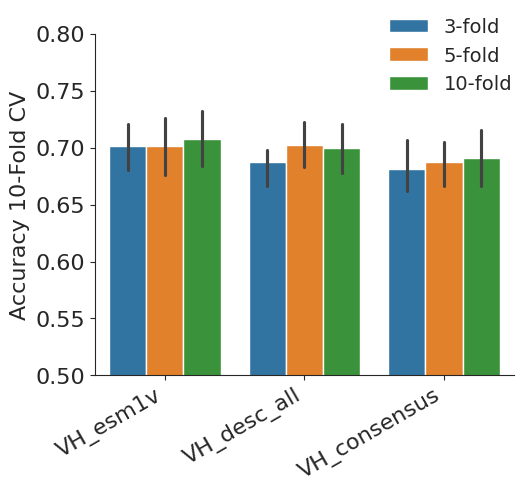

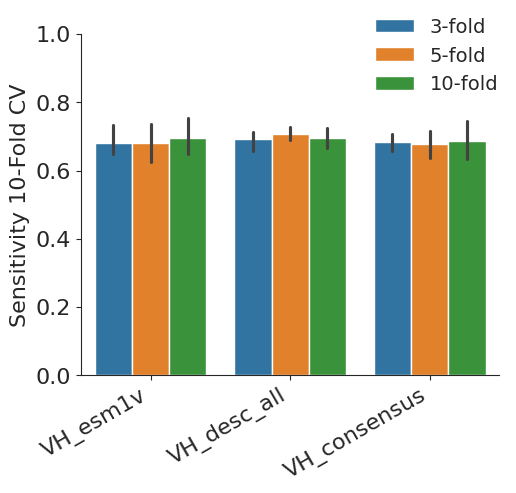

<Figure size 640x480 with 0 Axes>

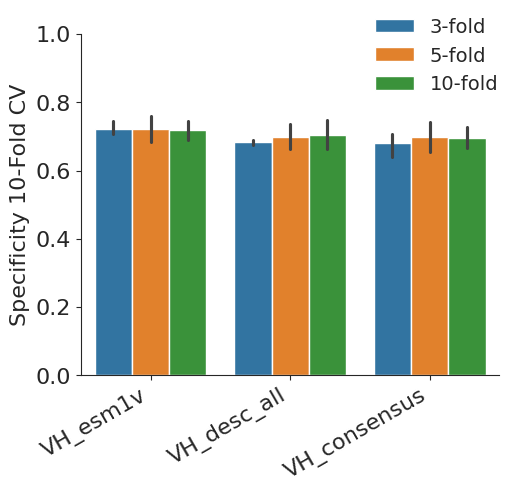

In [82]:
# --- Read result outputs:
consensus_kFoldCV_results_path = ['./Data/Consensus/Consensus_model_two_classes_VH_esm1v-desc_all_3CV_results.xlsx',
                                  './Data/Consensus/Consensus_model_two_classes_VH_esm1v-desc_all_5CV_results.xlsx',
                                  './Data/Consensus/Consensus_model_two_classes_VH_esm1v-desc_all_10CV_results.xlsx',
                                  ]

ref_baseline_kFoldCV_results_path = ['./Data/Consensus/Ref_desc_model_two_classes_VH_desc_all_3CV_results.xlsx', 
                                     './Data/Consensus/Ref_desc_model_two_classes_VH_desc_all_5CV_results.xlsx', 
                                     './Data/Consensus/Ref_desc_model_two_classes_VH_desc_all_10CV_results.xlsx', 
                                     ]

ref_PLM_kFoldCV_results_path = ['./Data/Consensus/Ref_PLM_model_two_classes_VH_esm1v_3CV_results.xlsx', 
                                './Data/Consensus/Ref_PLM_model_two_classes_VH_esm1v_5CV_results.xlsx', 
                                './Data/Consensus/Ref_PLM_model_two_classes_VH_esm1v_10CV_results.xlsx', 
                                ]


table_2classes_concat_list = []
for i in range(len(consensus_kFoldCV_results_path)):
    d1 = pd.read_excel(consensus_kFoldCV_results_path[i])
    d2 = pd.read_excel(ref_baseline_kFoldCV_results_path[i])
    d3 = pd.read_excel(ref_PLM_kFoldCV_results_path[i])
    table_2classes_concat = pd.concat([d1, d2, d3])
    table_2classes_concat_list.append(table_2classes_concat)
    
consensus_3CV_concat = table_2classes_concat_list[0]
consensus_5CV_concat = table_2classes_concat_list[1]
consensus_10CV_concat = table_2classes_concat_list[2]

consensus_3CV_concat.reset_index(drop=True, inplace=True)
consensus_5CV_concat.reset_index(drop=True, inplace=True)
consensus_10CV_concat.reset_index(drop=True, inplace=True)

# --- Consolidate kFold into one dF:
consensus_3CV_concat['CV'] = ['3-fold' for i in range(len(consensus_3CV_concat['feat']))]
consensus_5CV_concat['CV'] = ['5-fold' for i in range(len(consensus_5CV_concat['feat']))]
consensus_10CV_concat['CV'] = ['10-fold' for i in range(len(consensus_10CV_concat['feat']))]

table_2classes = pd.concat([consensus_3CV_concat, consensus_5CV_concat, consensus_10CV_concat]).reset_index(drop=True)

# --- Visualise:
y_lim_1 = [0.5,0,0]
y_lim_2 = [0.8,1,1]
for i, y_axis in enumerate(['accuracy','sensitivity','specificity']):
    plt.figure(1)
    sns.set_style('ticks')
    sns.set_palette(sns.color_palette('tab10'))
    g1 =sns.catplot(data=table_2classes,
                    x='feat', 
                    y=y_axis,
                    kind='bar',
                    hue='CV',
                    order=['VH_esm1v', 'VH_desc_all', 'VH_consensus'],
                    hue_order=['3-fold', '5-fold', '10-fold'],
                    legend_out=False,
                    )

    plt.xticks(rotation=30,ha='right',fontsize=16)
    plt.yticks(fontsize=16)
    plt.ylim(y_lim_1[i],y_lim_2[i])
    #plt.title('Consensus model',fontsize=16)
    plt.legend(title='',loc="upper center", bbox_to_anchor=(0.85, 1.1), ncol=1,frameon=False,borderaxespad=0.5,fontsize=14)
    plt.rcParams['legend.title_fontsize'] = 'x-large'
    g1.fig.set_figwidth(5)
    g1.fig.set_figheight(4)

    if y_axis == 'sensitivity':
        plt.ylabel('Sensitivity 10-Fold CV',fontsize=16)
    else:
        plt.ylabel(y_axis.capitalize() +' 10-Fold CV',fontsize=16)
    plt.xlabel('')
    plt.savefig('./Figures/Bar plots/FigS22_kFold_CV_'+y_axis+'_combined_VH_model.pdf',dpi=300, bbox_inches='tight')



## Results VH/VL-based models:

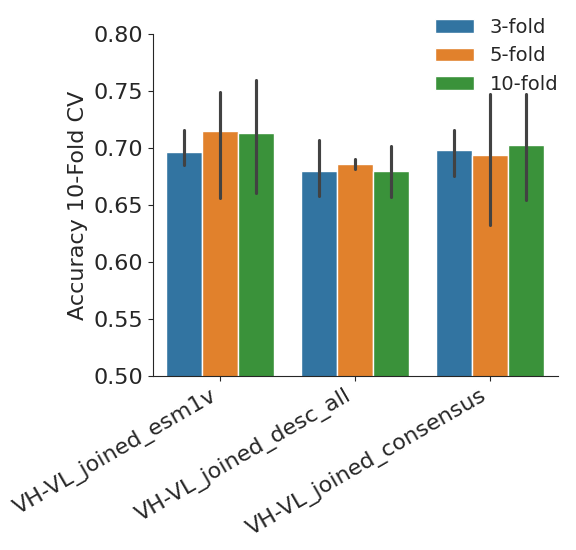

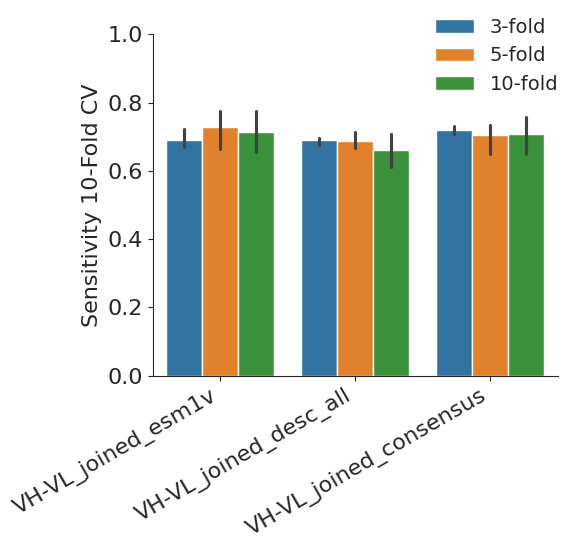

<Figure size 640x480 with 0 Axes>

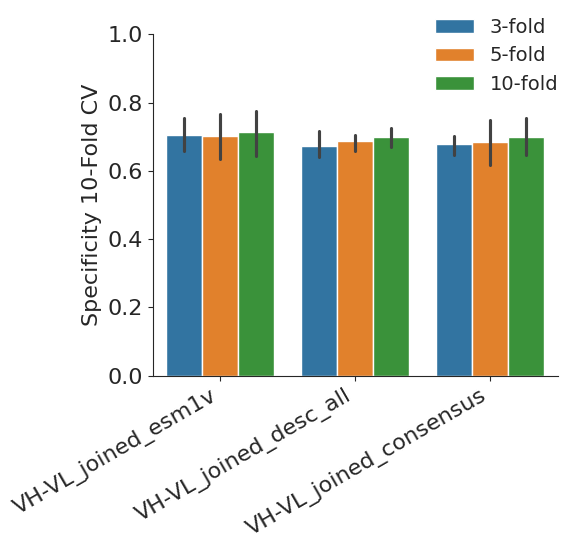

In [85]:
# --- Read result outputs:
consensus_kFoldCV_results_path = ['./Data/Consensus/Consensus_model_two_classes_VH_VL_joined_esm1v-desc_all_3CV_results.xlsx',
                                  './Data/Consensus/Consensus_model_two_classes_VH_VL_joined_esm1v-desc_all_5CV_results.xlsx',
                                  './Data/Consensus/Consensus_model_two_classes_VH_VL_joined_esm1v-desc_all_10CV_results.xlsx',
                                  ]

ref_baseline_kFoldCV_results_path = ['./Data/Consensus/Ref_desc_model_two_classes_VH_VL_joined_desc_all_3CV_results.xlsx', 
                                     './Data/Consensus/Ref_desc_model_two_classes_VH_VL_joined_desc_all_5CV_results.xlsx', 
                                     './Data/Consensus/Ref_desc_model_two_classes_VH_VL_joined_desc_all_10CV_results.xlsx', 
                                     ]

ref_PLM_kFoldCV_results_path = ['./Data/Consensus/Ref_PLM_model_two_classes_VH_VL_joined_esm1v_3CV_results.xlsx', 
                                './Data/Consensus/Ref_PLM_model_two_classes_VH_VL_joined_esm1v_5CV_results.xlsx', 
                                './Data/Consensus/Ref_PLM_model_two_classes_VH_VL_joined_esm1v_10CV_results.xlsx', 
                                ]


table_2classes_concat_list = []
for i in range(len(consensus_kFoldCV_results_path)):
    d1 = pd.read_excel(consensus_kFoldCV_results_path[i])
    d2 = pd.read_excel(ref_baseline_kFoldCV_results_path[i])
    d3 = pd.read_excel(ref_PLM_kFoldCV_results_path[i])
    table_2classes_concat = pd.concat([d1, d2, d3])
    table_2classes_concat_list.append(table_2classes_concat)
    
consensus_3CV_concat = table_2classes_concat_list[0]
consensus_5CV_concat = table_2classes_concat_list[1]
consensus_10CV_concat = table_2classes_concat_list[2]

consensus_3CV_concat.reset_index(drop=True, inplace=True)
consensus_5CV_concat.reset_index(drop=True, inplace=True)
consensus_10CV_concat.reset_index(drop=True, inplace=True)

# --- Consolidate kFold into one dF:
consensus_3CV_concat['CV'] = ['3-fold' for i in range(len(consensus_3CV_concat['feat']))]
consensus_5CV_concat['CV'] = ['5-fold' for i in range(len(consensus_5CV_concat['feat']))]
consensus_10CV_concat['CV'] = ['10-fold' for i in range(len(consensus_10CV_concat['feat']))]

table_2classes = pd.concat([consensus_3CV_concat, consensus_5CV_concat, consensus_10CV_concat]).reset_index(drop=True)

# --- Visualise:
y_lim_1 = [0.5,0,0]
y_lim_2 = [0.8,1,1]
for i, y_axis in enumerate(['accuracy','sensitivity','specificity']):
    plt.figure(1)
    sns.set_style('ticks')
    sns.set_palette(sns.color_palette('tab10'))
    g1 =sns.catplot(data=table_2classes,
                    x='feat', 
                    y=y_axis,
                    kind='bar',
                    hue='CV',
                    order=['VH-VL_joined_esm1v', 'VH-VL_joined_desc_all', 'VH-VL_joined_consensus'],
                    hue_order=['3-fold', '5-fold', '10-fold'],
                    legend_out=False,
                    )

    plt.xticks(rotation=30,ha='right',fontsize=16)
    plt.yticks(fontsize=16)
    plt.ylim(y_lim_1[i],y_lim_2[i])
    #plt.title('Consensus model',fontsize=16)
    plt.legend(title='',loc="upper center", bbox_to_anchor=(0.85, 1.1), ncol=1,frameon=False,borderaxespad=0.5,fontsize=14)
    plt.rcParams['legend.title_fontsize'] = 'x-large'
    g1.fig.set_figwidth(5)
    g1.fig.set_figheight(4)

    if y_axis == 'sensitivity':
        plt.ylabel('Sensitivity 10-Fold CV',fontsize=16)
    else:
        plt.ylabel(y_axis.capitalize() +' 10-Fold CV',fontsize=16)
    plt.xlabel('')
    plt.savefig('./Figures/Bar plots/FigS22_kFold_CV_'+y_axis+'_combined_VH_VL_joined_model.pdf',dpi=300, bbox_inches='tight')

